# 4 - Teste

Este notebook executa a avaliacao final no conjunto de teste usando os artefatos produzidos nas etapas anteriores. A regra aqui e simples: nada de reescalar com informacao do teste e nada de reajustar hiperparametros com base nos resultados desta etapa.


## 1. Ambiente

Se necessario:

```python
# %pip install torch pyarrow pandas numpy matplotlib scikit-learn
```


In [ ]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch import nn

#usa o mesmo criterio de device adotado no treino
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## 2. Carga de dados e configuracoes

Este notebook assume que `2-pre-processamento.ipynb` e `3-treino-validacao.ipynb` ja foram executados e que os artefatos estao presentes em `artifacts/`.


In [ ]:
PROJECT_ROOT = Path.cwd()
PREPROCESSED_DIR = PROJECT_ROOT / "artifacts" / "preprocessed"
MODELS_DIR = PROJECT_ROOT / "artifacts" / "models"

#recupera a configuracao salva junto com o modelo treinado
with (MODELS_DIR / "lstm_forecaster_standard_config.json").open() as fh:
    config = json.load(fh)

#carrega o conjunto de teste ja escalado com a estrategia usada no treino
test_df = pd.read_parquet(PREPROCESSED_DIR / f"test_{config['scaler_name']}.parquet")
print("Test shape:", test_df.shape)
config


Test shape: (3222, 6)


{'sequence_length': 30,
 'input_size': 6,
 'hidden_size': 64,
 'num_layers': 2,
 'dropout': 0.2,
 'scaler_name': 'standard',
 'max_epochs': 50,
 'patience': 7,
 'best_epoch': 23,
 'best_val_loss': 0.06647551737725735,
 'executed_epochs': 30}

## 3. Reconstrucao do modelo

O modelo precisa ser recriado com a mesma arquitetura usada no treino antes de carregar os pesos salvos.


In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.head = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        output, _ = self.lstm(x)
        #mantem a mesma logica do treino usando o ultimo estado da janela
        last_hidden = output[:, -1, :]
        return self.head(last_hidden)


def create_sequences(dataframe: pd.DataFrame, sequence_length: int):
    #gera as janelas temporais do conjunto de teste
    values = dataframe.to_numpy(dtype=np.float32)
    sequences = []
    targets = []
    for start_idx in range(len(values) - sequence_length):
        end_idx = start_idx + sequence_length
        sequences.append(values[start_idx:end_idx])
        targets.append(values[end_idx])
    return (
        torch.tensor(np.stack(sequences), dtype=torch.float32),
        torch.tensor(np.stack(targets), dtype=torch.float32),
    )


X_test, y_test = create_sequences(test_df, sequence_length=config["sequence_length"])
model = LSTMForecaster(
    input_size=config["input_size"],
    hidden_size=config["hidden_size"],
    num_layers=config["num_layers"],
    dropout=config["dropout"],
).to(device)
#carrega os pesos aprendidos na etapa de treino
model.load_state_dict(torch.load(MODELS_DIR / "lstm_forecaster_standard.pt", map_location=device))
model.eval()

print(f"X_test: {tuple(X_test.shape)} | y_test: {tuple(y_test.shape)}")


X_test: (3192, 30, 6) | y_test: (3192, 6)


## 4. Inferencia e metricas

Como o alvo deste baseline e a proxima observacao multivariada, as metricas abaixo resumem o erro medio no espaco escalado. Depois, se necessario, voce pode inverter o scaler e calcular metricas em unidades fisicas.


In [ ]:
#desabilita gradientes porque aqui so queremos inferencia
with torch.no_grad():
    preds = model(X_test.to(device)).cpu().numpy()

y_true = y_test.numpy()

#colapsa todas as features e todos os passos para metricas globais simples
mse = mean_squared_error(y_true.reshape(-1), preds.reshape(-1))
rmse = float(np.sqrt(mse))
mae = mean_absolute_error(y_true.reshape(-1), preds.reshape(-1))

metrics_df = pd.DataFrame(
    {
        "metric": ["MSE", "RMSE", "MAE"],
        "value": [mse, rmse, mae],
    }
)
metrics_df


,metric,value
0,MSE,0.428819
1,RMSE,0.654842
2,MAE,0.475725


In [ ]:
#tambem calcula erro por feature para identificar sensores mais dificeis
feature_names = test_df.columns.tolist()
per_feature_metrics = pd.DataFrame(
    {
        "feature": feature_names,
        "mae": np.mean(np.abs(y_true - preds), axis=0),
        "rmse": np.sqrt(np.mean((y_true - preds) ** 2, axis=0)),
    }
).sort_values("rmse", ascending=False)

per_feature_metrics.head(15)


,feature,mae,rmse
1,P-JUS-CKGL,1.215497,1.313882
0,P-ANULAR,0.577404,0.594144
3,P-TPT,0.458250,0.531194
5,T-TPT,0.331179,0.393002
4,T-JUS-CKP,0.148393,0.179450
2,P-MON-CKP,0.123623,0.157481


## 5. Visualizacao rapida

O grafico abaixo ajuda a comparar previsto versus observado para uma feature escolhida. Para uma analise mais completa, repita o grafico em outras variaveis de interesse.


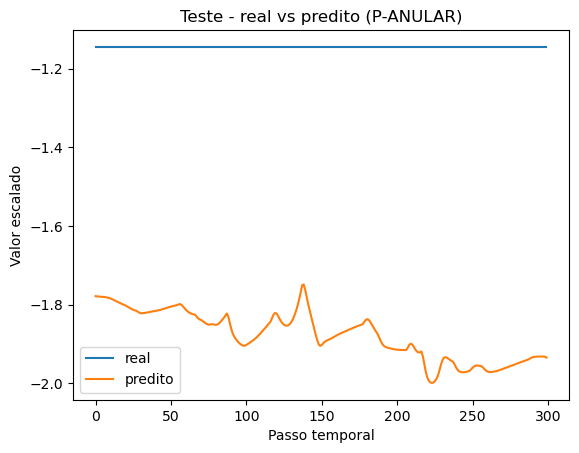

In [ ]:
#escolhe uma feature para inspecao visual rapida da previsao
feature_to_plot = test_df.columns[0]
feature_idx = test_df.columns.get_loc(feature_to_plot)

plot_df = pd.DataFrame(
    {
        "real": y_true[:, feature_idx],
        "predito": preds[:, feature_idx],
    }
)

#limita a visualizacao aos primeiros passos para manter o grafico legivel
plot_df.iloc[:300].plot(title=f"Teste - real vs predito ({feature_to_plot})")
plt.xlabel("Passo temporal")
plt.ylabel("Valor escalado")
plt.show()


## 6. Fechamento

Este notebook encerra a esteira basica de avaliacao. Se o desempenho estiver fraco, os pontos mais promissores para iteracao costumam ser: revisao do pre-processamento por tipo de sensor, redefinicao do alvo, teste de outro scaler, ajuste do comprimento da janela temporal e refinamento da arquitetura LSTM.
